# LPJ-GUESS → CLM PFT conversion

This notebook defines, documents, validates, and exports the PFT correspondence used to translate LPJ-GUESS natural PFT groups into CLM natural-PFT indices.

It contains **only the conversion scheme**. It does not load FPC fields, regrid data, modify `PCT_NAT_PFT`, or create a surface dataset.

The exported CSV is deliberately machine-readable: the CLM numeric index and abbreviation are stored in separate columns, and mapped, bare-ground, and excluded PFTs have explicit treatments.

## Mapping decisions

- Trees are matched primarily by growth form, leaf form, and phenology.
- `BNE` and `BINE` both map to boreal needleleaf evergreen trees because CLM does not distinguish their shade-tolerance strategies.
- `IBS` maps to boreal broadleaf deciduous trees for this >45°N application.
- High, low, and prostrate dwarf shrubs map to CLM's single boreal shrub PFT, `BoBDS`. This necessarily maps evergreen shrubs to a deciduous CLM shrub because no evergreen boreal shrub PFT exists.
- `C3G` and `GRT` map to arctic C3 grass.
- LPJ-GUESS `CLM` (cushion forb, lichen, and moss) maps to bare ground because no corresponding natural PFT is used here.
- Peatland PFTs are recorded but excluded from this conversion.
- CLM natural-PFT index 13 (`C3`) is not modified by this scheme.

## 1. Setup

In [1]:
from pathlib import Path
from textwrap import fill

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages

OUTPUT_DIR = Path("PFT_conversion")
CSV_PATH = OUTPUT_DIR / "lpjguess_to_clm_pft_conversion.csv"
PDF_PATH = OUTPUT_DIR / "lpjguess_to_clm_pft_conversion.pdf"
FIGURE_DIR = OUTPUT_DIR / "figures"

DATA = Path("/nird/datapeak/NS9188K/adelez/BRL-FRST-XPSN/data/edit-surfdata")
SURF_IN = DATA / "surfdata_1.9x2.5_hist_78pfts_CMIP6_simyr2000_c190304.nc"
FPC_HIST = DATA / "LPJ-GUESS/fpc1971to2000_max.txt"
FPC_FUT = DATA / "LPJ-GUESS/GFDL-ESM4_SSP585_fpc2071to2100_max.txt"
SURF_OUT = DATA / "surfdata_1.9x2.5_SSP5-8.5_2100_78pfts_LPJGUESS.nc"


## 2. Define the PFT metadata and conversion

In [2]:
LPJ_NATURAL = [
    "BNE", "BINE", "BNS", "TeNE", "TeBE", "IBS", "TeBS", "C3G",
    "HSE", "HSS", "LSE", "LSS", "GRT", "EPDS", "SPDS", "CLM",
]

LPJ_PEATLAND = ["pLSE", "pLSS", "pCLM", "WetGRS", "pmoss", "C3G_wet", "C4G_wet"]

LPJ_NAMES = {
    "BNE": "Boreal needle-leaved evergreen tree",
    "BINE": "Boreal shade-intolerant needle-leaved evergreen tree",
    "BNS": "Boreal needle-leaved summergreen tree",
    "TeNE": "Temperate needle-leaved evergreen tree",
    "TeBE": "Temperate broad-leaved evergreen tree",
    "IBS": "Shade-intolerant broad-leaved summergreen tree",
    "TeBS": "Temperate broad-leaved summergreen tree",
    "C3G": "Cold C3 grass",
    "HSE": "High shrub evergreen",
    "HSS": "High shrub summergreen",
    "LSE": "Low shrub evergreen",
    "LSS": "Low shrub summergreen",
    "GRT": "Graminoid and forb tundra",
    "EPDS": "Evergreen prostrate dwarf shrub (needleleaved)",
    "SPDS": "Summergreen prostrate dwarf shrub (broadleaved)",
    "CLM": "Cushion forb, lichen and moss",
    "pLSE": "Peatland low shrub evergreen",
    "pLSS": "Peatland low shrub summergreen",
    "pCLM": "Peatland cushion/forb",
    "WetGRS": "Flood-tolerant grass/graminoid",
    "pmoss": "Peatland moss",
    "C3G_wet": "Peatland C3 grass",
    "C4G_wet": "Peatland C4 grass",
}

VEGETATION_GROUP = {
    **{pft: "tree" for pft in ["BNE", "BINE", "BNS", "TeNE", "TeBE", "IBS", "TeBS"]},
    **{pft: "grass" for pft in ["C3G", "GRT"]},
    **{pft: "shrub" for pft in ["HSE", "HSS", "LSE", "LSS", "EPDS", "SPDS"]},
    "CLM": "non-vascular",
    **{pft: "peatland" for pft in LPJ_PEATLAND},
}

CLM_NAMES = {
    0: "BG", 1: "TeNET", 2: "BoNET", 3: "BoNDT", 4: "TrBET",
    5: "TeBET", 6: "TrBDT", 7: "TeBDT", 8: "BoBDT",
    9: "TeBES", 10: "TeBDS", 11: "BoBDS", 12: "arcticC3",
    13: "C3", 14: "C4",
}

# CLM natpft index -> LPJ-GUESS PFTs summed into that target.
CONVERSION_SCHEME = {
    1: ["TeNE"],
    2: ["BNE", "BINE"],
    3: ["BNS"],
    5: ["TeBE"],
    7: ["TeBS"],
    8: ["IBS"],
    11: ["HSE", "HSS", "LSE", "LSS", "EPDS", "SPDS"],
    12: ["C3G", "GRT"],
}

BARE = 0

## 3. Validate the declared mapping

In [3]:
mapped_natural = [pft for pfts in CONVERSION_SCHEME.values() for pft in pfts]
expected_mapped = set(LPJ_NATURAL) - {"CLM"}

assert len(mapped_natural) == len(set(mapped_natural)), "An LPJ PFT is mapped more than once."
assert set(mapped_natural) == expected_mapped, (
    "Natural-PFT coverage mismatch: "
    f"missing={sorted(expected_mapped - set(mapped_natural))}, "
    f"unexpected={sorted(set(mapped_natural) - expected_mapped)}"
)
assert set(CONVERSION_SCHEME).issubset(CLM_NAMES), "Unknown CLM natpft index."
assert 13 not in CONVERSION_SCHEME, "CLM C3 (natpft 13) should remain untouched."

print(f"Validated {len(mapped_natural)} mapped natural PFTs.")
print("Validated CLM -> bare-ground treatment separately.")
print(f"Recorded {len(LPJ_PEATLAND)} excluded peatland PFTs.")

Validated 15 mapped natural PFTs.
Validated CLM -> bare-ground treatment separately.
Recorded 7 excluded peatland PFTs.


## 4. Build and export the reusable table

In [4]:
lpj_to_clm_id = {
    lpj_pft: clm_id
    for clm_id, lpj_pfts in CONVERSION_SCHEME.items()
    for lpj_pft in lpj_pfts
}
lpj_to_clm_id["CLM"] = BARE

rows = []
all_lpj_pfts = LPJ_NATURAL + LPJ_PEATLAND

for lpj_index, lpj_abbrev in enumerate(all_lpj_pfts):
    clm_id = lpj_to_clm_id.get(lpj_abbrev)

    if lpj_abbrev == "CLM":
        treatment = "mapped_to_bare"
        note = "No corresponding natural CLM PFT is used in this conversion."
    elif clm_id is not None:
        treatment = "mapped"
        note = ""
    else:
        treatment = "excluded"
        note = "Peatland PFT; excluded from the natural-PFT conversion."

    rows.append({
        "lpj_index": lpj_index,
        "lpj_abbrev": lpj_abbrev,
        "lpj_name": LPJ_NAMES[lpj_abbrev],
        "vegetation_group": VEGETATION_GROUP[lpj_abbrev],
        "clm_natpft": clm_id,
        "clm_abbrev": CLM_NAMES.get(clm_id),
        "treatment": treatment,
        "note": note,
    })

conversion_table = pd.DataFrame(rows)
conversion_table["clm_natpft"] = conversion_table["clm_natpft"].astype("Int64")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
conversion_table.to_csv(CSV_PATH, index=False)

print(f"Saved: {CSV_PATH}")
conversion_table

Saved: PFT_conversion/lpjguess_to_clm_pft_conversion.csv


,lpj_index,lpj_abbrev,lpj_name,vegetation_group,clm_natpft,clm_abbrev,treatment,note
0,0,BNE,Boreal needle-leaved evergreen tree,tree,2,BoNET,mapped,
1,1,BINE,Boreal shade-intolerant needle-leaved evergree...,tree,2,BoNET,mapped,
2,2,BNS,Boreal needle-leaved summergreen tree,tree,3,BoNDT,mapped,
3,3,TeNE,Temperate needle-leaved evergreen tree,tree,1,TeNET,mapped,
4,4,TeBE,Temperate broad-leaved evergreen tree,tree,5,TeBET,mapped,
5,5,IBS,Shade-intolerant broad-leaved summergreen tree,tree,8,BoBDT,mapped,
6,6,TeBS,Temperate broad-leaved summergreen tree,tree,7,TeBDT,mapped,
7,7,C3G,Cold C3 grass,grass,12,arcticC3,mapped,
8,8,HSE,High shrub evergreen,shrub,11,BoBDS,mapped,
9,9,HSS,High shrub summergreen,shrub,11,BoBDS,mapped,


## 5. Export a readable PDF table

In [5]:
def save_conversion_pdf(table, path, rows_per_page=25):
    # Save the correspondence as a readable A3-landscape PDF.
    columns = [
        "lpj_abbrev", "lpj_name", "vegetation_group",
        "clm_natpft", "clm_abbrev", "treatment",
    ]
    headers = [
        "LPJ abbrev.", "LPJ-GUESS PFT", "Group",
        "CLM index", "CLM PFT", "Treatment",
    ]

    printable = table[columns].copy()
    printable["lpj_name"] = printable["lpj_name"].map(lambda value: fill(value, 36))
    printable["clm_natpft"] = printable["clm_natpft"].astype("string").fillna("-")
    printable["clm_abbrev"] = printable["clm_abbrev"].fillna("-")
    printable["treatment"] = printable["treatment"].str.replace("_", " ")

    page_count = (len(printable) + rows_per_page - 1) // rows_per_page
    row_colors = {
        "mapped": "#E8F3E8",
        "mapped to bare": "#FFF2CC",
        "excluded": "#ECECEC",
    }

    with PdfPages(path) as pdf:
        for page_number, start in enumerate(range(0, len(printable), rows_per_page), 1):
            page = printable.iloc[start:start + rows_per_page]
            fig, ax = plt.subplots(figsize=(16.54, 11.69))
            ax.axis("off")

            fig.suptitle(
                "LPJ-GUESS to CLM PFT conversion",
                x=0.04, y=0.96, ha="left", fontsize=16, fontweight="bold",
            )
            ax.set_title(
                "Mapping exported by LPJGUESS_to_CLM_PFT_conversion.ipynb",
                loc="left", fontsize=9, color="0.35", pad=12,
            )

            pdf_table = ax.table(
                cellText=page.values,
                colLabels=headers,
                cellLoc="left",
                colLoc="left",
                colWidths=[0.10, 0.34, 0.12, 0.09, 0.10, 0.17],
                bbox=[0.0, 0.08, 1.0, 0.82],
            )
            pdf_table.auto_set_font_size(False)
            pdf_table.set_fontsize(8.5)

            for column in range(len(headers)):
                cell = pdf_table[0, column]
                cell.set_facecolor("#244A3A")
                cell.set_text_props(color="white", fontweight="bold")
                cell.set_edgecolor("white")

            for row_number, treatment in enumerate(page["treatment"], 1):
                for column in range(len(headers)):
                    cell = pdf_table[row_number, column]
                    cell.set_facecolor(row_colors[treatment])
                    cell.set_edgecolor("white")
                    cell.set_linewidth(1.0)
                    cell.get_text().set_va("center")

            fig.text(
                0.04, 0.035,
                "Green: mapped   |   Yellow: mapped to bare ground   |   Grey: excluded",
                ha="left", fontsize=8, color="0.3",
            )
            fig.text(
                0.96, 0.035, f"Page {page_number} of {page_count}",
                ha="right", fontsize=8, color="0.3",
            )
            pdf.savefig(fig)
            plt.close(fig)


save_conversion_pdf(conversion_table, PDF_PATH)
print(f"Saved: {PDF_PATH}")

Saved: PFT_conversion/lpjguess_to_clm_pft_conversion.pdf


## 6. Reload and verify reusability

In [9]:
reloaded = pd.read_csv(CSV_PATH)
mapped = reloaded.loc[reloaded["treatment"].eq("mapped")].copy()
mapped["clm_natpft"] = mapped["clm_natpft"].astype(int)

reconstructed_scheme = (
    mapped.groupby("clm_natpft", sort=True)["lpj_abbrev"]
    .apply(list)
    .to_dict()
)

assert reconstructed_scheme == CONVERSION_SCHEME
print("Reload check passed. Reconstructed conversion scheme:")
reconstructed_scheme

Reload check passed. Reconstructed conversion scheme:


{1: ['TeNE'],
 2: ['BNE', 'BINE'],
 3: ['BNS'],
 5: ['TeBE'],
 7: ['TeBS'],
 8: ['IBS'],
 11: ['HSE', 'HSS', 'LSE', 'LSS', 'EPDS', 'SPDS'],
 12: ['C3G', 'GRT']}

## 7. Map setup and data loaders

The maps use the same circular Arctic projection and `gist_earth_r` palette as the reference figures. LPJ-GUESS aggregation is performed on the native LPJ grid; no spatial regridding is applied in this notebook.

In [21]:
import matplotlib.colors as mcolors
import matplotlib.path as mpath
import numpy as np
import xarray as xr
import cartopy.crs as ccrs

plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 11,
    "axes.titlesize": 12,
})

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

PFTS_TO_PLOT = list(CONVERSION_SCHEME)
PLOT_CLM_NAMES = {**CLM_NAMES, 12: "aC3"}

CLM_LEVELS = np.arange(0, 101, 5)
CLM_TICKS = np.arange(0, 91, 15)
LPJ_LEVELS = np.arange(0, 0.76, 0.05)
LPJ_TICKS = np.arange(0, 0.71, 0.1)

In [22]:
def convert_lsmcoord(dataset):
    # Replace CLM index dimensions with the actual latitude and longitude.
    if {"lat", "lon"}.issubset(dataset.dims):
        return dataset
    required = {"lsmlat", "lsmlon", "LATIXY", "LONGXY"}
    missing = required - set(dataset.dims) - set(dataset.variables)
    if missing:
        raise ValueError(f"Cannot identify CLM coordinates; missing: {sorted(missing)}")

    converted = dataset.copy()
    converted["lsmlat"] = converted["LATIXY"].isel(lsmlon=0)
    converted["lsmlon"] = converted["LONGXY"].isel(lsmlat=0)
    return converted.rename({"lsmlat": "lat", "lsmlon": "lon"})


def convert360_180(data):
    # Convert 0...360 longitudes to -180...180 and sort them.
    if float(data["lon"].min()) >= 0:
        data = data.assign_coords(lon=((data["lon"] + 180) % 360) - 180)
        data = data.sortby("lon")
    return data


def load_lpjguess_fpc(path, pfts=LPJ_NATURAL):
    # Read the whitespace table, remove repeated headers, validate, and grid it.
    raw = pd.read_csv(path, sep=r"\s+", dtype=str)
    required = ["Lon", "Lat", *pfts]
    missing = sorted(set(required) - set(raw.columns))
    if missing:
        raise ValueError(f"Missing LPJ-GUESS columns in {path}: {missing}")

    numeric_coordinates = (
        pd.to_numeric(raw["Lon"], errors="coerce").notna()
        & pd.to_numeric(raw["Lat"], errors="coerce").notna()
    )
    table = raw.loc[numeric_coordinates, required].copy()
    table[required] = table[required].apply(pd.to_numeric, errors="raise")

    duplicated = table.duplicated(["Lat", "Lon"], keep=False)
    if duplicated.any():
        examples = table.loc[duplicated, ["Lon", "Lat"]].head().to_dict("records")
        raise ValueError(f"Duplicate LPJ-GUESS coordinates; examples: {examples}")
    if table[pfts].isna().any().any():
        raise ValueError("Missing FPC values found inside retained LPJ-GUESS rows.")
    if (table[pfts] < -1e-10).any().any():
        raise ValueError("Negative LPJ-GUESS FPC values found.")

    indexed = table.set_index(["Lat", "Lon"])[pfts].sort_index()
    gridded = indexed.to_xarray().to_array("natpft")
    return gridded.rename({"Lat": "lat", "Lon": "lon"}).transpose("natpft", "lat", "lon")


def aggregate_to_clm(fpc_named, scheme=CONVERSION_SCHEME):
    # Preserve NaN cells: an absent LPJ grid cell must not become zero cover.
    fields = [
        fpc_named.sel(natpft=source_pfts)
        .sum("natpft", skipna=False)
        .expand_dims(natpft=[clm_id])
        for clm_id, source_pfts in scheme.items()
    ]
    return xr.concat(fields, dim="natpft").sortby("natpft")

In [23]:
def save_figure(figure, name, dpi=220):
    for extension in ("png", "pdf"):
        path = FIGURE_DIR / f"{name}.{extension}"
        figure.savefig(path, dpi=dpi, bbox_inches="tight")
        print(f"Saved: {path}")


def circular_boundary(axis):
    theta = np.linspace(0, 2 * np.pi, 200)
    vertices = np.column_stack([np.sin(theta), np.cos(theta)]) * 0.5 + 0.5
    axis.set_boundary(mpath.Path(vertices), transform=axis.transAxes)


def polar_map_panel(fields, titles, levels, ticks, colorbar_label, ncols=4):
    nplots = len(fields)
    nrows = int(np.ceil(nplots / ncols))
    figure, axes = plt.subplots(
        nrows, ncols,
        figsize=(3.25 * ncols, 3.35 * nrows + 0.7),
        subplot_kw={"projection": ccrs.Orthographic(0, 90)},
        layout="constrained",
    )
    axes = np.atleast_1d(axes).ravel()

    colormap = plt.get_cmap("gist_earth_r", len(levels) - 1).copy()
    colormap.set_bad("white")
    colormap.set_under("white")
    colormap.set_over("black")
    norm = mcolors.BoundaryNorm(levels, colormap.N, clip=False)

    mappable = None
    for axis, field, title in zip(axes, fields, titles):
        axis.set_extent([-180, 180, 45, 90], crs=ccrs.PlateCarree())
        circular_boundary(axis)
        axis.set_facecolor("white")
        mappable = field.plot.pcolormesh(
            ax=axis, x="lon", y="lat", transform=ccrs.PlateCarree(),
            cmap=colormap, norm=norm, add_colorbar=False,
        )
        axis.coastlines(linewidth=0.45, color="0.2")
        axis.gridlines(linewidth=0.4, color="0.65", alpha=0.35)
        axis.set_title(title, pad=7)

    for axis in axes[nplots:]:
        axis.set_visible(False)

    colorbar = figure.colorbar(
        mappable, ax=list(axes[:nplots]), orientation="horizontal",
        ticks=ticks, extend="both", fraction=0.045, pad=0.045, aspect=45,
    )
    colorbar.set_label(colorbar_label)
    return figure

## 8. Load the CLM and historical LPJ-GUESS inputs

In [24]:
for input_path in (SURF_IN, FPC_HIST):
    if not input_path.exists():
        raise FileNotFoundError(input_path)

with xr.open_dataset(SURF_IN) as surface_dataset:
    surface = convert_lsmcoord(surface_dataset)
    pct_clm = convert360_180(surface["PCT_NAT_PFT"]).load()
    land_fraction = convert360_180(surface["LANDFRAC_PFT"]).load()
    natural_vegetation = convert360_180(surface["PCT_NATVEG"]).load()

valid_clm = (
    (land_fraction > 0)
    & (natural_vegetation > 0)
    & (abs(pct_clm.sum("natpft") - 100) < 1e-3)
).fillna(False)

fpc_hist = convert360_180(load_lpjguess_fpc(FPC_HIST))
fpc_hist_aggregated = aggregate_to_clm(fpc_hist)

print(f"Valid CLM natural-vegetation cells: {int(valid_clm.sum())}")
print(f"LPJ-GUESS grid: {fpc_hist.sizes['lat']} latitudes x {fpc_hist.sizes['lon']} longitudes")
print(f"Maximum original-PFT FPC: {float(fpc_hist.max(skipna=True)):.3f}")
print(f"Maximum aggregated FPC: {float(fpc_hist_aggregated.max(skipna=True)):.3f}")

Valid CLM natural-vegetation cells: 4914
LPJ-GUESS grid: 75 latitudes x 638 longitudes
Maximum original-PFT FPC: 0.827
Maximum aggregated FPC: 0.883


## 9. CLM natural-PFT distribution

Saved: PFT_conversion/figures/clm_pct_nat_pft_2000.png
Saved: PFT_conversion/figures/clm_pct_nat_pft_2000.pdf


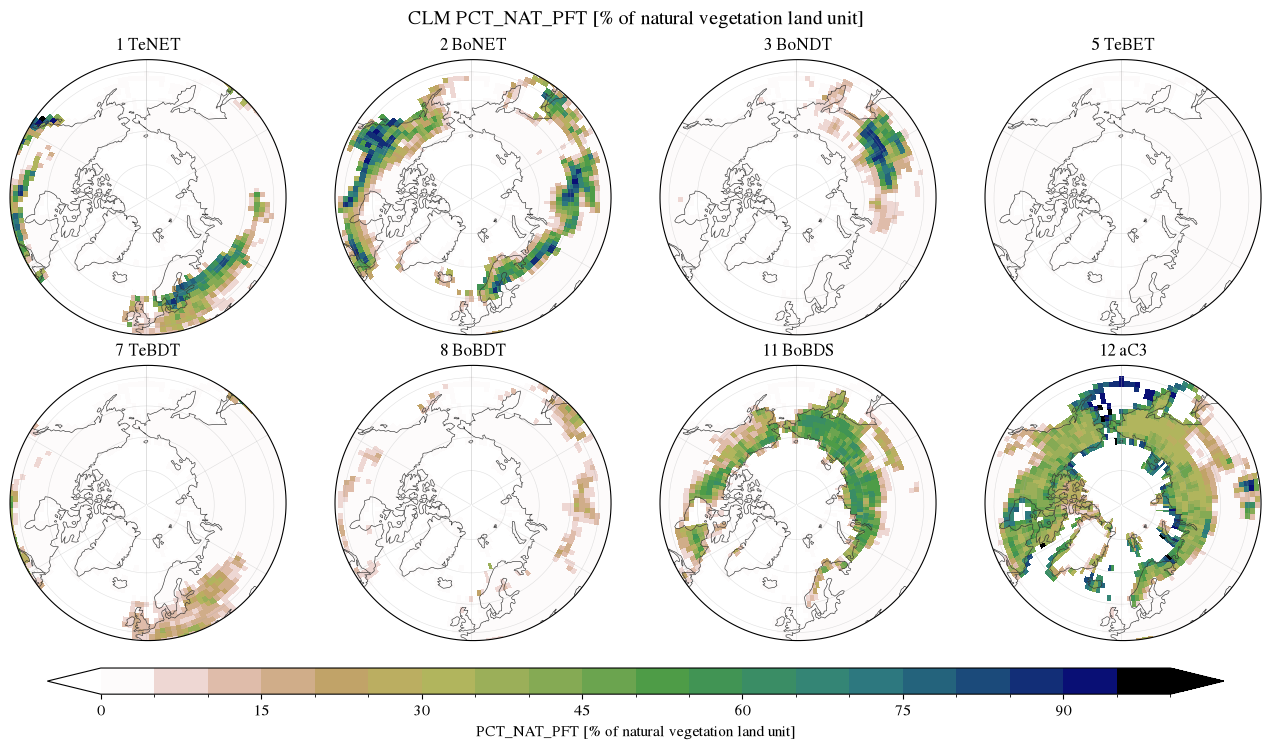

In [25]:
figure = polar_map_panel(
    [pct_clm.sel(natpft=pft).where(valid_clm) for pft in PFTS_TO_PLOT],
    [f"{pft} {PLOT_CLM_NAMES[pft]}" for pft in PFTS_TO_PLOT],
    levels=CLM_LEVELS,
    ticks=CLM_TICKS,
    colorbar_label="PCT_NAT_PFT [% of natural vegetation land unit]",
)
figure.suptitle("CLM PCT_NAT_PFT [% of natural vegetation land unit]", fontsize=14)
save_figure(figure, "clm_pct_nat_pft_2000")
plt.show()

## 10. LPJ-GUESS historical FPC by original PFT

Saved: PFT_conversion/figures/lpjguess_fpc_1971_2000_original_pfts.png
Saved: PFT_conversion/figures/lpjguess_fpc_1971_2000_original_pfts.pdf


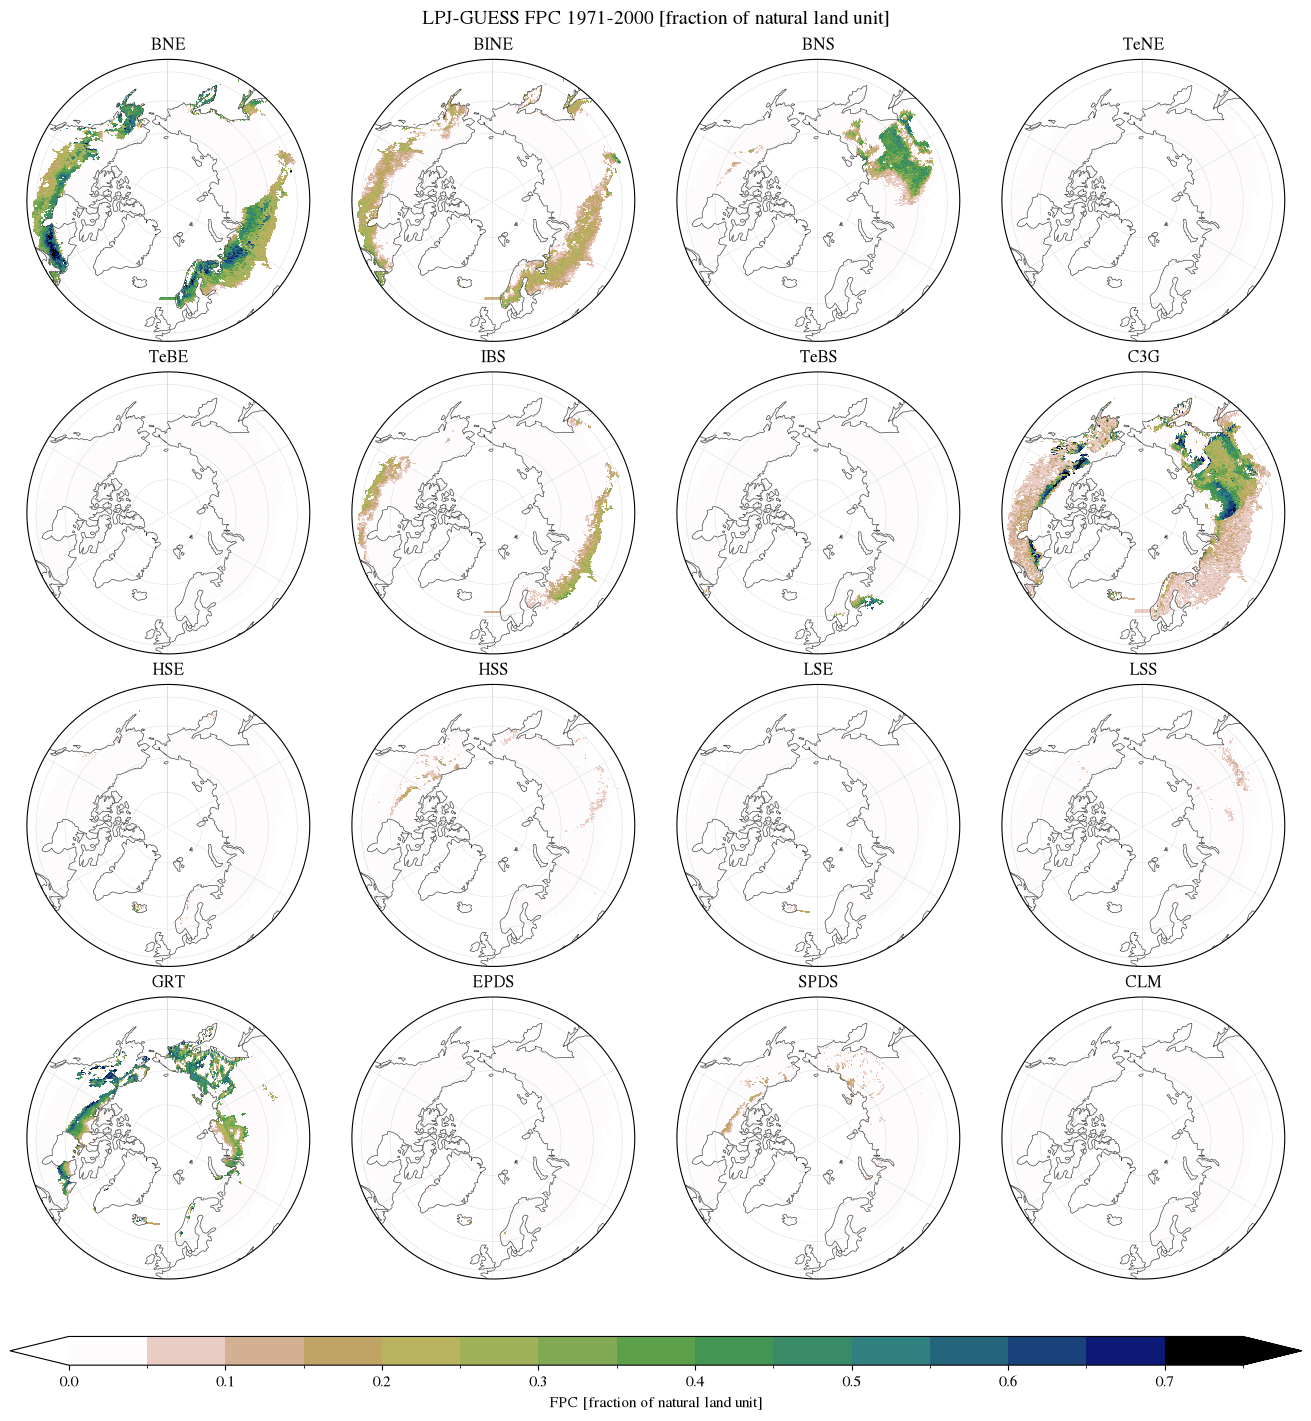

In [26]:
figure = polar_map_panel(
    [fpc_hist.sel(natpft=pft) for pft in LPJ_NATURAL],
    LPJ_NATURAL,
    levels=LPJ_LEVELS,
    ticks=LPJ_TICKS,
    colorbar_label="FPC [fraction of natural land unit]",
)
figure.suptitle("LPJ-GUESS FPC 1971-2000 [fraction of natural land unit]", fontsize=14)
save_figure(figure, "lpjguess_fpc_1971_2000_original_pfts")
plt.show()

## 11. LPJ-GUESS historical FPC aggregated into CLM PFTs

The PFT components are summed without normalization or clipping. Therefore an aggregated group can exceed 1 where LPJ-GUESS PFTs overlap structurally. The shared 0–0.7 scale is retained for comparison with the original-PFT figure; over-range values use black.

Saved: PFT_conversion/figures/lpjguess_fpc_1971_2000_aggregated_clm_pfts.png
Saved: PFT_conversion/figures/lpjguess_fpc_1971_2000_aggregated_clm_pfts.pdf


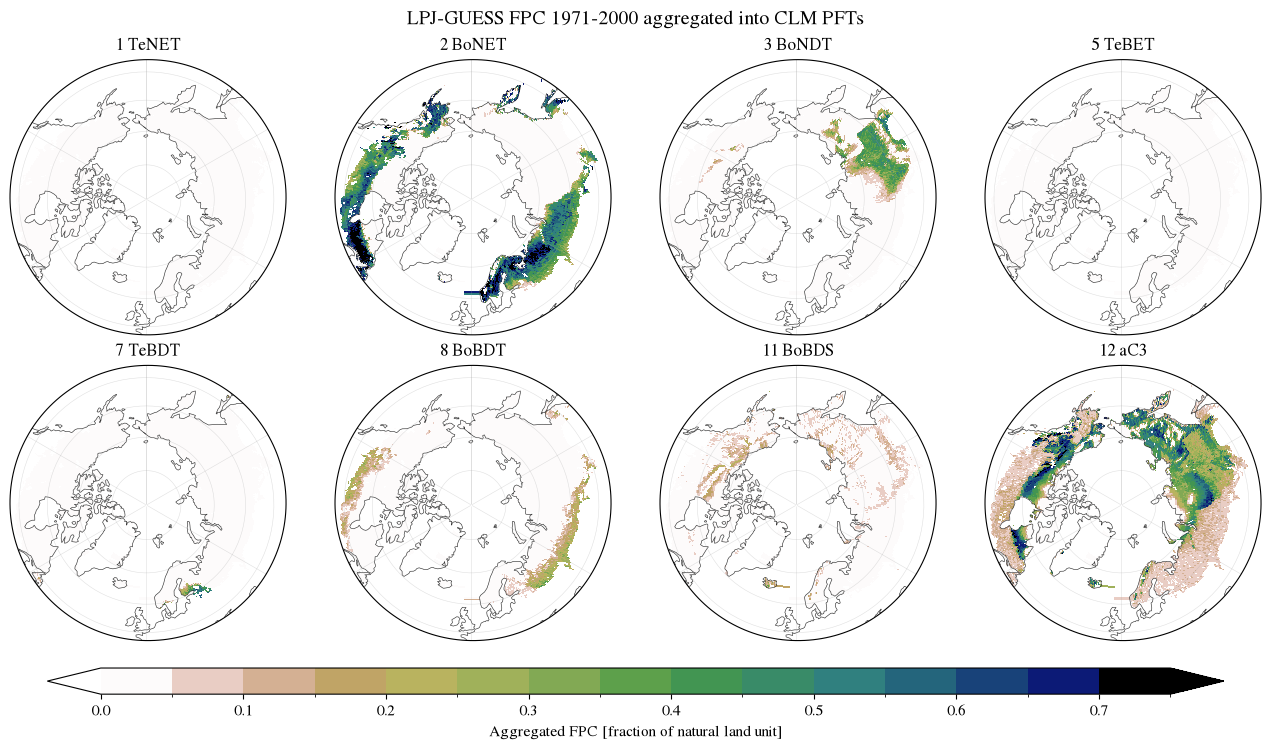

In [27]:
figure = polar_map_panel(
    [fpc_hist_aggregated.sel(natpft=pft) for pft in PFTS_TO_PLOT],
    [f"{pft} {PLOT_CLM_NAMES[pft]}" for pft in PFTS_TO_PLOT],
    levels=LPJ_LEVELS,
    ticks=LPJ_TICKS,
    colorbar_label="Aggregated FPC [fraction of natural land unit]",
)
figure.suptitle(
    "LPJ-GUESS FPC 1971-2000 aggregated into CLM PFTs",
    fontsize=14,
)
save_figure(figure, "lpjguess_fpc_1971_2000_aggregated_clm_pfts")
plt.show()

## Output

Running the notebook creates:

`PFT_conversion/lpjguess_to_clm_pft_conversion.csv`

`PFT_conversion/lpjguess_to_clm_pft_conversion.pdf`

`PFT_conversion/figures/clm_pct_nat_pft_2000.[png|pdf]`

`PFT_conversion/figures/lpjguess_fpc_1971_2000_original_pfts.[png|pdf]`

`PFT_conversion/figures/lpjguess_fpc_1971_2000_aggregated_clm_pfts.[png|pdf]`

Later workflows can read the CSV and reconstruct `CONVERSION_SCHEME` without copying the mapping manually. The PDF provides the same correspondence in a human-readable format.

## Mapss of CLM PFTs masked over LPJGUESS coverage

In [28]:
# %% Regrid the LPJ-GUESS domain mask to the CLM grid

import xesmf as xe

GRIDLIST = DATA / "LPJ-GUESS/gridlist45N_tundraboreal.txt"

# Retain a CLM cell when it has any non-negligible overlap with the LPJ domain.
MASK_COVERAGE_THRESHOLD = 1e-12


def coordinate_bounds(centres, latitude=False):
    """Calculate cell boundaries from one-dimensional cell centres."""
    centres = np.asarray(centres, dtype=float)
    midpoints = 0.5 * (centres[:-1] + centres[1:])

    bounds = np.concatenate([
        [centres[0] - (midpoints[0] - centres[0])],
        midpoints,
        [centres[-1] + (centres[-1] - midpoints[-1])],
    ])

    return np.clip(bounds, -90, 90) if latitude else bounds


def conservative_grid(latitudes, longitudes):
    """Construct a grid containing the bounds required by xESMF."""
    return xr.Dataset({
        "lat": ("lat", latitudes),
        "lon": ("lon", longitudes),
        "lat_b": ("lat_b", coordinate_bounds(latitudes, latitude=True)),
        "lon_b": ("lon_b", coordinate_bounds(longitudes)),
    })


gridlist = pd.read_csv(
    GRIDLIST,
    sep=r"\s+",
    names=["lon", "lat"],
    dtype=float,
)

if gridlist.duplicated(["lon", "lat"]).any():
    raise ValueError("Duplicate coordinates found in the LPJ-GUESS grid list.")

# The supplied grid list uses a regular 0.5° grid.
resolution = 0.5

source_lon = np.arange(-180 + resolution / 2, 180, resolution)
source_lat = np.arange(
    gridlist["lat"].min(),
    gridlist["lat"].max() + resolution / 2,
    resolution,
)

mask_values = np.zeros(
    (source_lat.size, source_lon.size),
    dtype=np.float32,
)

lon_index = np.rint(
    (gridlist["lon"].to_numpy() - source_lon[0]) / resolution
).astype(int)

lat_index = np.rint(
    (gridlist["lat"].to_numpy() - source_lat[0]) / resolution
).astype(int)

if not (
    np.allclose(source_lon[lon_index], gridlist["lon"])
    and np.allclose(source_lat[lat_index], gridlist["lat"])
):
    raise ValueError("Grid-list coordinates do not match the reconstructed grid.")

mask_values[lat_index, lon_index] = 1.0

lpj_mask_native = xr.DataArray(
    mask_values,
    coords={"lat": source_lat, "lon": source_lon},
    dims=("lat", "lon"),
    name="lpjguess_domain_mask",
)

source_grid = conservative_grid(
    lpj_mask_native.lat.values,
    lpj_mask_native.lon.values,
)

target_grid = conservative_grid(
    pct_clm.lat.values,
    pct_clm.lon.values,
)

mask_regridder = xe.Regridder(
    source_grid,
    target_grid,
    method="conservative",
    periodic=True,
)

lpj_coverage_clm = (
    mask_regridder(lpj_mask_native)
    .fillna(0)
    .clip(min=0, max=1)
)

lpj_coverage_clm.name = "LPJGUESS_COVERAGE"

In [29]:
# %% Mask CLM PCT_NAT_PFT outside the LPJ-GUESS domain

lpj_mask_clm = (
    (lpj_coverage_clm > MASK_COVERAGE_THRESHOLD)
    & valid_clm
)

pct_clm_lpj_domain = pct_clm.where(lpj_mask_clm)

print(f"LPJ-GUESS source cells: {int(lpj_mask_native.sum()):,}")
print(f"Valid CLM cells before masking: {int(valid_clm.sum()):,}")
print(f"CLM cells retained: {int(lpj_mask_clm.sum()):,}")

LPJ-GUESS source cells: 16,750
Valid CLM cells before masking: 4,914
CLM cells retained: 1,309


Saved: PFT_conversion/figures/clm_pct_nat_pft_2000_lpjguess_domain.png
Saved: PFT_conversion/figures/clm_pct_nat_pft_2000_lpjguess_domain.pdf


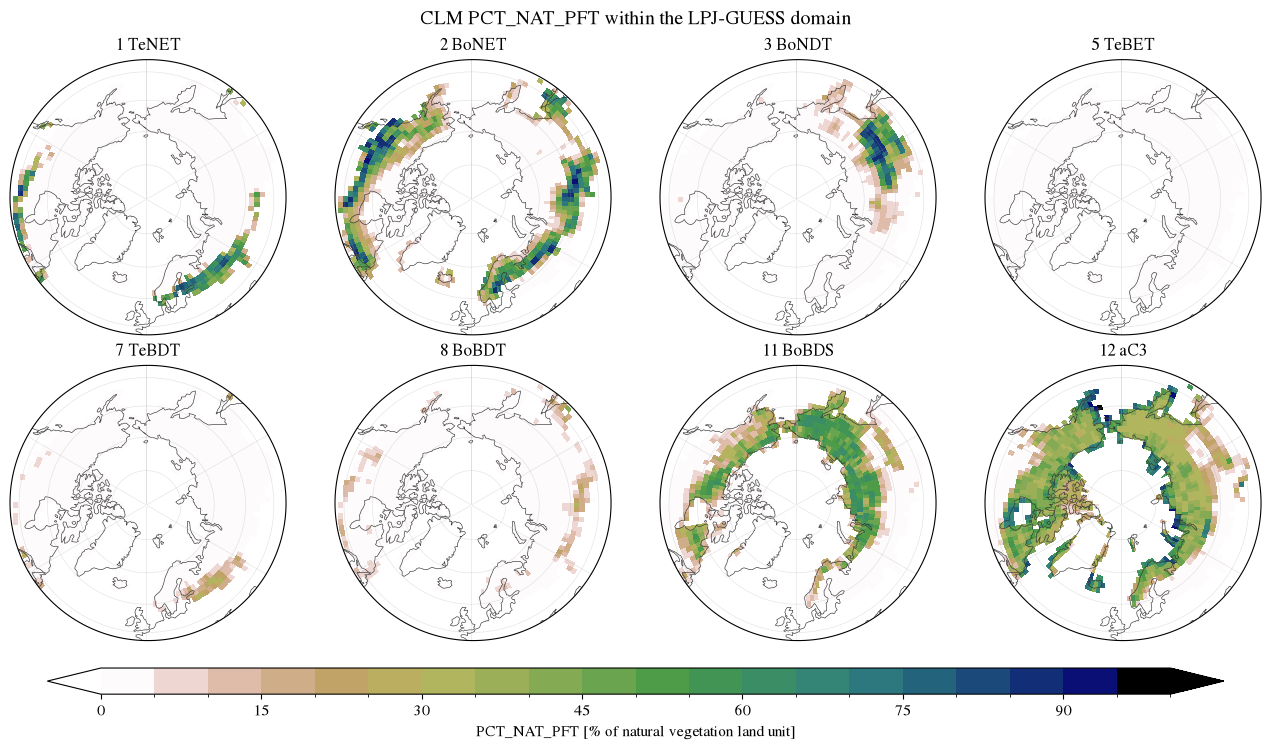

In [30]:
# %% CLM PFTs restricted to the LPJ-GUESS domain

figure = polar_map_panel(
    [
        pct_clm_lpj_domain.sel(natpft=pft)
        for pft in PFTS_TO_PLOT
    ],
    [
        f"{pft} {PLOT_CLM_NAMES[pft]}"
        for pft in PFTS_TO_PLOT
    ],
    levels=CLM_LEVELS,
    ticks=CLM_TICKS,
    colorbar_label="PCT_NAT_PFT [% of natural vegetation land unit]",
)

figure.suptitle(
    "CLM PCT_NAT_PFT within the LPJ-GUESS domain",
    fontsize=14,
)

save_figure(figure, "clm_pct_nat_pft_2000_lpjguess_domain")
plt.show()

## Future minus historical FPC aggregated into CLM PFT groups

In [31]:
fpc_fut = convert360_180(load_lpjguess_fpc(FPC_FUT))

# Fail if historical and future data do not have identical grids and PFTs.
fpc_hist, fpc_fut = xr.align(
    fpc_hist,
    fpc_fut,
    join="exact",
)

fpc_fut_aggregated = aggregate_to_clm(fpc_fut)

# Aggregation and differencing are both linear operations.
delta_fpc_aggregated = (
    fpc_fut_aggregated
    - fpc_hist_aggregated
)

delta_fpc_aggregated.name = "delta_fpc"
delta_fpc_aggregated.attrs = {
    "long_name": (
        "Future minus historical LPJ-GUESS FPC "
        "aggregated into CLM PFT groups"
    ),
    "units": "fraction of natural land unit",
    "historical_period": "1971-2000",
    "future_period": "2071-2100",
    "scenario": "GFDL-ESM4 SSP5-8.5",
}

print(
    "Aggregated FPC change range: "
    f"{float(delta_fpc_aggregated.min(skipna=True)):.3f} to "
    f"{float(delta_fpc_aggregated.max(skipna=True)):.3f}"
)

Aggregated FPC change range: -0.734 to 0.847


In [32]:
# %% Plotting helper for signed FPC changes

DELTA_LEVELS = np.linspace(-0.55, 0.55, 12)
DELTA_TICKS = [-0.5, -0.25, 0, 0.25, 0.5]


def polar_difference_panel(
    fields,
    titles,
    levels=DELTA_LEVELS,
    ticks=DELTA_TICKS,
    colorbar_label="FPC change [fraction of natural land unit]",
    ncols=4,
):
    """Plot signed changes using a shared zero-centred colour scale."""
    nplots = len(fields)
    nrows = int(np.ceil(nplots / ncols))

    figure, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(3.25 * ncols, 3.35 * nrows + 0.7),
        subplot_kw={"projection": ccrs.Orthographic(0, 90)},
        layout="constrained",
    )

    axes = np.atleast_1d(axes).ravel()

    colormap = plt.get_cmap("BrBG", len(levels) - 1).copy()
    colormap.set_bad("white")

    norm = mcolors.BoundaryNorm(
        levels,
        colormap.N,
        clip=False,
    )

    mappable = None

    for axis, field, title in zip(axes, fields, titles):
        axis.set_extent(
            [-180, 180, 45, 90],
            crs=ccrs.PlateCarree(),
        )

        circular_boundary(axis)
        axis.set_facecolor("white")

        mappable = field.plot.pcolormesh(
            ax=axis,
            x="lon",
            y="lat",
            transform=ccrs.PlateCarree(),
            cmap=colormap,
            norm=norm,
            add_colorbar=False,
        )

        axis.coastlines(
            linewidth=0.45,
            color="0.2",
        )

        axis.gridlines(
            linewidth=0.4,
            color="0.65",
            alpha=0.35,
        )

        axis.set_title(title, pad=7)

    for axis in axes[nplots:]:
        axis.set_visible(False)

    colorbar = figure.colorbar(
        mappable,
        ax=list(axes[:nplots]),
        orientation="horizontal",
        ticks=ticks,
        extend="both",
        fraction=0.045,
        pad=0.045,
        aspect=45,
    )

    colorbar.set_label(colorbar_label)

    return figure

Saved: PFT_conversion/figures/lpjguess_fpc_change_2071_2100_minus_1971_2000_aggregated_clm_pfts.png
Saved: PFT_conversion/figures/lpjguess_fpc_change_2071_2100_minus_1971_2000_aggregated_clm_pfts.pdf


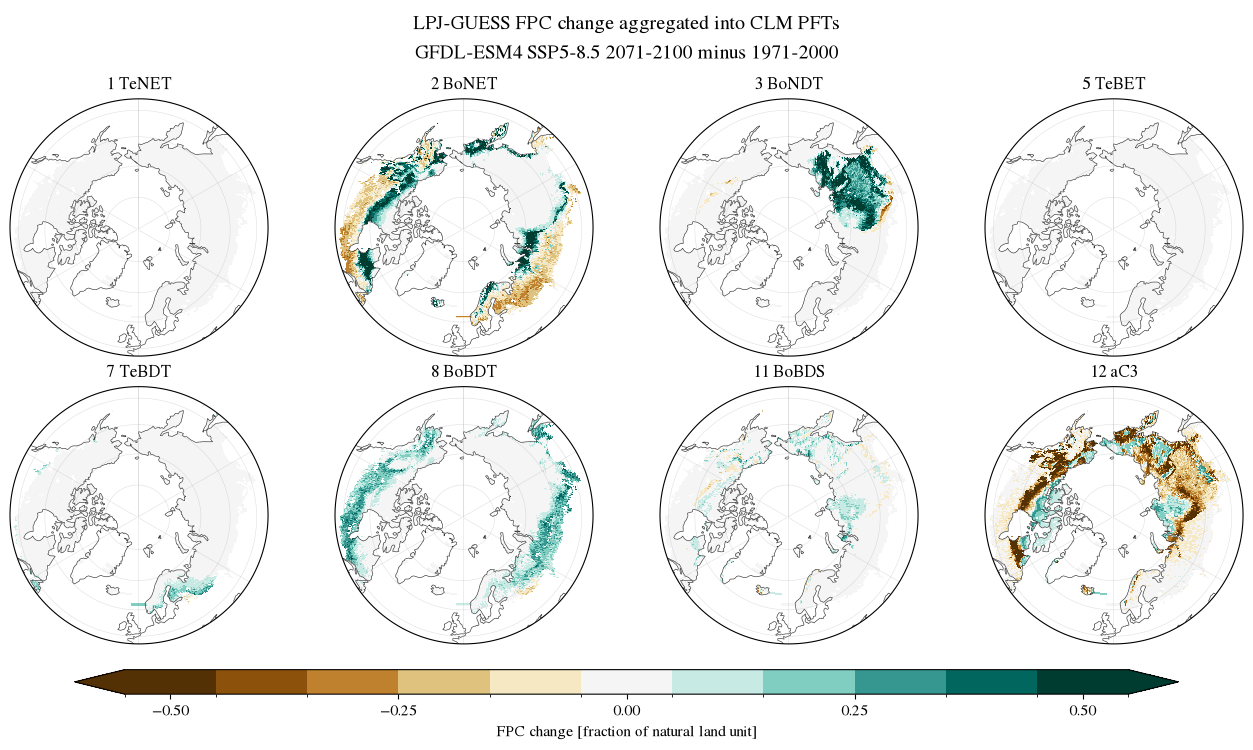

In [33]:
# %% Map future minus historical FPC in CLM PFT groups

figure = polar_difference_panel(
    [
        delta_fpc_aggregated.sel(natpft=pft)
        for pft in PFTS_TO_PLOT
    ],
    [
        f"{pft} {PLOT_CLM_NAMES[pft]}"
        for pft in PFTS_TO_PLOT
    ],
)

figure.suptitle(
    "LPJ-GUESS FPC change aggregated into CLM PFTs\n"
    "GFDL-ESM4 SSP5-8.5 2071-2100 minus 1971-2000",
    fontsize=14,
)

save_figure(
    figure,
    "lpjguess_fpc_change_2071_2100_minus_1971_2000_aggregated_clm_pfts",
)

plt.show()